# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Isabelle Rosa Frank
* Username: irfrank
* Student number: S6414117
* Group (AS1, etc.): AS5

-----

In [ ]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

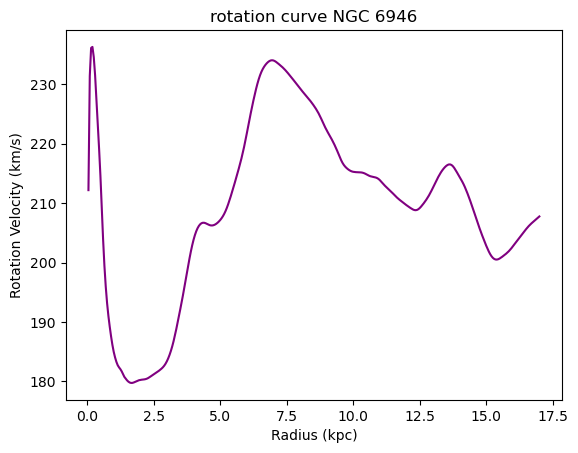

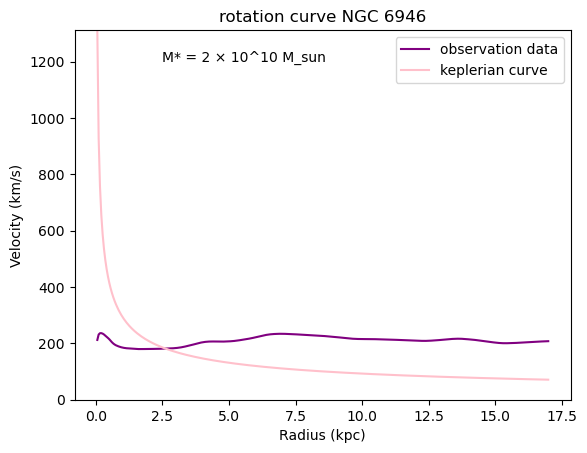

In [3]:
import numpy as np
import matplotlib.pyplot as plt

G=4.302e-6       #in kpc*M_sun^-1*km/s^2
M= 2e10          #in solar masses

#read columns as radius and velocity
data=np.loadtxt('rotcur.dat')
radius = data[:,0]              #in kpc
velocity = data[:,1]            #in km/s

#so v_k max does not go to infinity for the y limit
mask=radius>0
radius= radius[mask]
velocity=velocity[mask]

#plot
plt.figure()
plt.plot(radius, velocity, color='purple')
plt.xlabel('Radius (kpc)')
plt.ylabel('Rotation Velocity (km/s)')
plt.title('rotation curve NGC 6946')
plt.show()

#calculate Keplerian Rotation curve
v_kepler= np.sqrt(G*M/radius)          #in km/s

#save Keplerian curve
np.savetxt('keplerian_curve.txt', v_kepler)

#load data
v_k=np.loadtxt('keplerian_curve.txt')  #in km/s

#plot
plt.plot(radius, velocity, color='purple', label='observation data')
plt.plot(radius, v_k, color='pink', label='keplerian curve')
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title('rotation curve NGC 6946')
plt.legend()

#y axis limits
plt.ylim(0, np.max(v_k))

#annotation
plt.annotate("M* = 2 × 10^10 M_sun", xy=(2.5, 1200))

plt.legend()
plt.show()

comment about the observation: the observed rotation curve does not follow the keplerian rotation curve

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

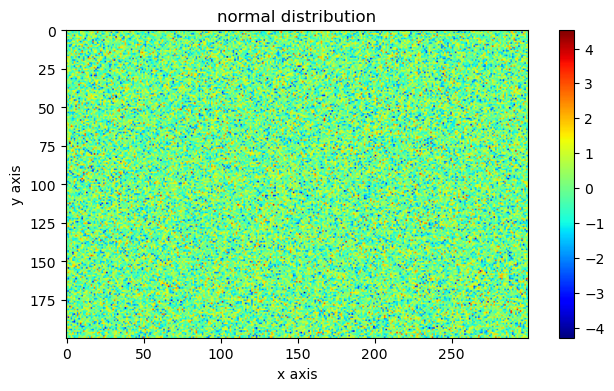

the mean= 0.011263149477989917
the standard deviation= 0.9631383606417968


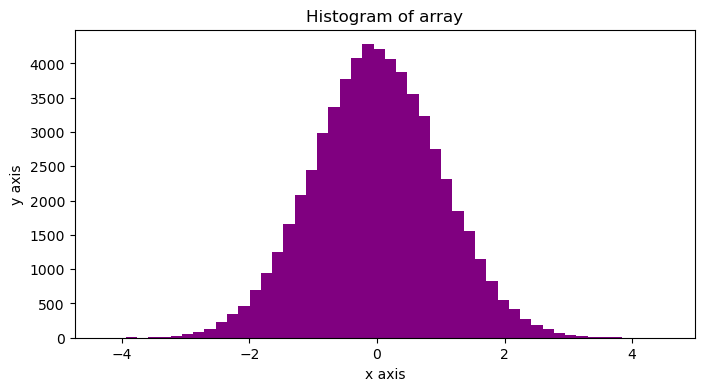

In [23]:
import numpy as np
import matplotlib.pyplot as plt

#create two dimensional Numpy array
array=np.random.normal(loc=0, scale=1.0, size=(200,300))

#plot the image
plt.figure(figsize=(8,4))
plt.imshow(array, cmap='jet')
plt.colorbar()
plt.title('normal distribution')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.show()

#small dimensional slice
pixel_slice=array[70:100, 70:100]
mean_slice=np.mean(pixel_slice)
std_slice=np.std(pixel_slice)

#calculate new mean and standard deviation
print(f'the mean= {mean_slice}')
print(f'the standard deviation= {std_slice}')

#flatten array
array=array.flatten()

#plot histogram
plt.figure(figsize=(8,4))
plt.hist(array, bins=50, color='purple')
plt.title('Histogram of array')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.show()

- The calculated mean and standard deviation are close to the given values which is expected.

- We should recongnise a normal distribution. (Gaussian distribution)

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Ellipse parameters: center=0, 0, semi major=3, semi minor=2, angle=0 with an Area= 18.84955592153876 and an perimeter 15.879014913585678
Ellipse parameters: center=0, 0, semi major=3, semi minor=2, angle=0


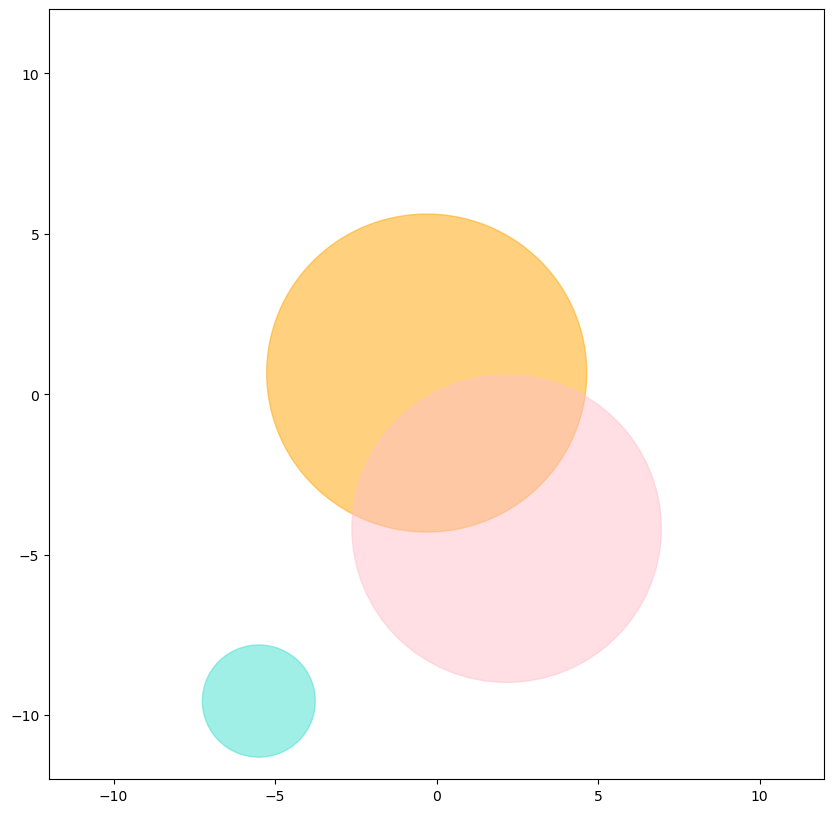

In [6]:
from matplotlib.patches import Ellipse

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        self.xc = xc
        self.yc = yc
        self.a = semi_major
        self.b = semi_minor
        self.position_angle=position_angle
        XY = (xc, yc)                  # MPL requires center as a tuple
        angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)
 #adding the method to calulate the area
    def area(self):
        A=np.pi*self.a*self.b
        return A
#adding the method to calculate the perimeter
    def perimeter(self):
        h=((self.a-self.b)**2)/((self.a + self.b)**2)
        P=np.pi*(self.a + self.b)* (1+3*h/(10+np.sqrt(4-3+h)))
        return P
#ading the method to return values of ellipse parameter
    def __str__(self):
        return (f'Ellipse parameters: center={self.xc}, {self.yc}, semi major={self.a}, semi minor={self.b}, angle={self.position_angle}')

#print an example for area and perimeter
example= AstroEllipse(xc=0,yc=0, semi_major=3, semi_minor=2, position_angle=0)
print(f'{example} with an Area= {example.area()} and an perimeter {example.perimeter()}')

#print an example for str method
print(example.__str__())

#create Class MyCircle

class MyCircle(AstroEllipse):
    def __init__(self, center, radius, **args):
        xc, yc = center
        self.radius=radius
        super().__init__(xc, yc, semi_major=radius, semi_minor=radius, position_angle=0, **args)

#plot the random circles
fig=plt.figure(figsize=(10,10))
frame=fig.add_subplot(1,1,1)
frame.set_xlim(-12, +12)
frame.set_ylim(-12,12)

colors=['orange', 'pink', 'turquoise']

for color in colors:
    center=np.random.uniform(-10,10,2)
    radius=np.random.uniform(1,5)
    circle=MyCircle(center,radius, color=color, alpha=0.5)
    frame.add_patch(circle)
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

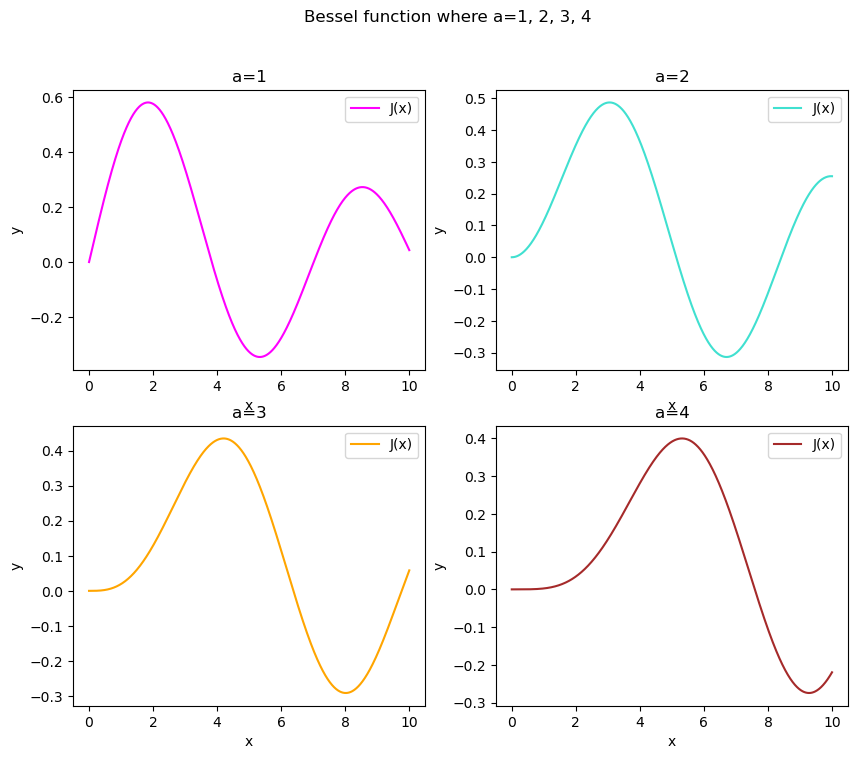

In [1]:
from scipy.special import jv
import numpy as np
import matplotlib.pyplot as plt

#get x values
x=np.linspace(0,10,1000)

#create figure
fig=plt.figure(figsize=(10,8))

#create 2x2 plots
frame1=fig.add_subplot(2,2,1)
frame2=fig.add_subplot(2,2,2)
frame3=fig.add_subplot(2,2,3)
frame4=fig.add_subplot(2,2,4)

#bessel function for a=1, 2, 3, 4
y1=jv(1,x)
frame1.plot(x,y1, color='magenta', label='J(x)')
frame1.set_title('a=1')
frame1.set_xlabel('x')
frame1.set_ylabel('y')
frame1.legend()

y2=jv(2,x)
frame2.plot(x,y2, color='turquoise', label='J(x)')
frame2.set_title('a=2')
frame2.set_xlabel('x')
frame2.set_ylabel('y')
frame2.legend()

y3=jv(3,x)
frame3.plot(x,y3, color='orange', label='J(x)')
frame3.set_title('a=3')
frame3.set_xlabel('x')
frame3.set_ylabel('y')
frame3.legend()

y4=jv(4,x)
frame4.plot(x,y4, color='brown', label='J(x)')
frame4.set_title('a=4')
frame4.set_xlabel('x')
frame4.set_ylabel('y')
frame4.legend()

fig.suptitle('Bessel function where a=1, 2, 3, 4')
plt.show()

#save the figure
fig.savefig('bessel.png', transparent=True)

<img src="bessel.png">

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

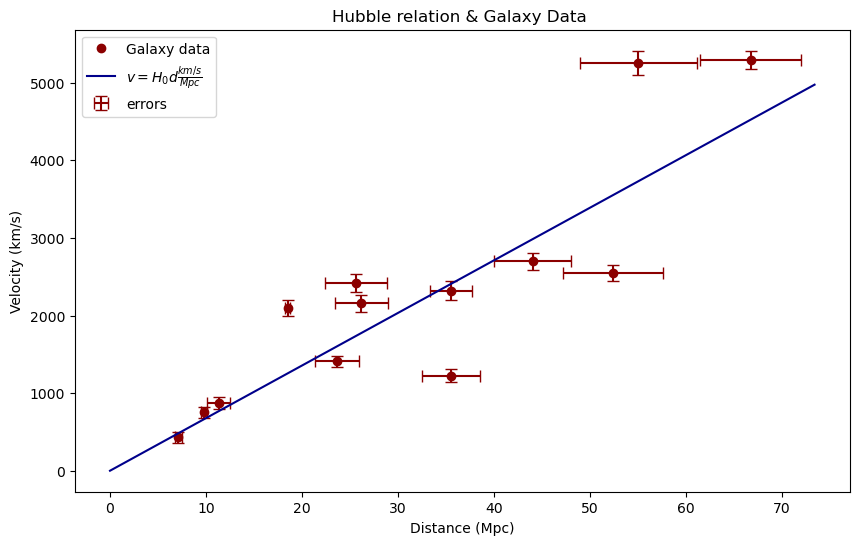

In [24]:
import numpy as np
import matplotlib.pyplot as plt

#import the data

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]

#unpack data into separate variables
data=np.array(data)
d= data[0::4]              #in Mpc
v= data[1::4]              #in km/s
d_error= data[2::4]        #in Mpc
v_error= data[3::4]        #in km/s

#add the Hubble constant
H_0=67.8                   #in (km/s)/Mpc

#creare figure
fig= plt.figure(figsize=(10,6))
frame= fig.add_subplot(1,1,1)

#add data points
frame.plot(d, v, 'o', color='darkred', label='Galaxy data')

#add error bars
frame.errorbar(d, v, xerr=d_error, yerr=v_error, fmt='none',capsize=4, color='darkred', label='errors')

#add Hubble line
x1=np.linspace(0,max(d)*1.1, 100)
y= H_0*x1
frame.plot(x1, y, color='darkblue', label=r'$v= H_0 d\frac{km/s}{Mpc}$')

frame.set_title('Hubble relation & Galaxy Data ')
frame.set_xlabel('Distance (Mpc)')
frame.set_ylabel('Velocity (km/s)')
frame.legend()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")